# Final Project 4: Reinforcement-Learning Agent

            ## 1. Learning objectives

            - Define a stochastic environment and success metric
- Compare Q-learning and SARSA across matched seeds
- Inspect Q-values and all required learning diagnostics

            ## 2. Prerequisites

            Complete the corresponding numbered course section and understand leakage-safe train/validation/test roles.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Reach a delayed goal efficiently despite an 8% action-slip probability. Success is high final reward and short episodes across seeds.

            ## 4. Real-world use cases

            - Sequential-control prototyping
- Algorithm comparison
- Reproducible RL evaluation

            ## 5. Core intuition in simple language

            A credible agent project documents the environment and reward, includes a baseline comparison, controls randomness, and reports noisy learning rather than one lucky score.

## 6. Mathematical foundation

            $$\delta=R+\gamma Q_{next}-Q(S,A),\qquad Q(S,A)\leftarrow Q(S,A)+\alpha\delta.$$

            **Every symbol:**

            - $\delta$ is temporal-difference error.
- $R$ is reward.
- $\gamma$ is discount.
- $Q_{next}$ is the method-specific bootstrap.
- $\alpha$ is learning rate.

            **Why the equation is needed:** Both algorithms share the TD correction while differing in how next action value is chosen.

            **Small numerical example:** With old Q=.2, reward 0, gamma=.9, next=.8, alpha=.5, new Q=.46.

            **Connection to Python:** td_update applies the shared correction; the training function selects max-Q for Q-learning or the behavior action for SARSA.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Define decision and success metric
2. Describe and audit data
3. Split before fitted preprocessing
4. Create a simple baseline
5. Compare candidate models
6. Tune on development data
7. Evaluate once on test data
8. Analyze errors and limitations

## 9. Implementation from scratch

A transparent baseline verifies label and metric semantics before complex modeling.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def td_update(old,target,alpha):
    return old+alpha*(target-old)
print("TD update check:",td_update(.2,.8,.5))

TD update check: 0.5


## 10. Implementation using a standard library

Standard libraries provide reproducible pipelines and robust implementations; decisions remain visible in code.

## 11. Dataset loading and exploration

The project uses a small bundled dataset so every result can be reproduced offline.

## 12. Data preprocessing

Cleaning and feature transformations are fitted only on development or training rows.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

,method,seed,final_reward,final_length
0,Q-learning,7,0.904,10.633
1,Q-learning,21,0.903,10.700
2,Q-learning,42,0.899,11.100
3,SARSA,7,0.905,10.500
4,SARSA,21,0.903,10.700
5,SARSA,42,0.901,10.867


final_reward        final_length       
                   mean    std         mean    std
method                                            
Q-learning        0.902  0.003       10.811  0.252
SARSA             0.903  0.002       10.689  0.184

Selected: SARSA
Q-table before training:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
Q-table during training:
 [[0.39 0.6 ]
 [0.43 0.64]
 [0.43 0.68]
 [0.55 0.74]
 [0.53 0.79]
 [0.67 0.86]
 [0.68 0.9 ]
 [0.78 0.95]
 [0.83 0.98]
 [0.   0.  ]]
Q-table after training:
 [[0.58 0.66]
 [0.55 0.7 ]
 [0.57 0.74]
 [0.61 0.78]
 [0.66 0.81]
 [0.72 0.85]
 [0.74 0.9 ]
 [0.82 0.94]
 [0.88 0.99]
 [0.   0.  ]]


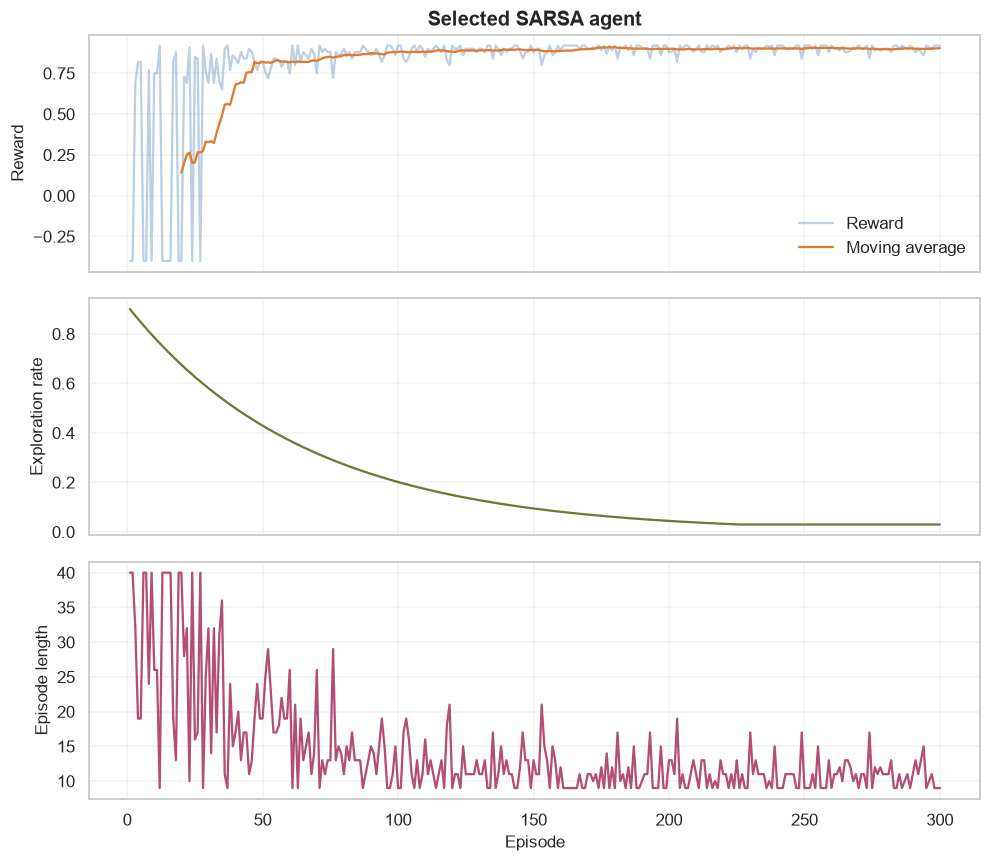

In [3]:
class GridLine:
    def __init__(self,length=10,max_steps=40,generator=None):
        self.length=length; self.max_steps=max_steps; self.generator=generator or np.random.default_rng(RANDOM_SEED)
    def reset(self): self.state=0; self.steps=0; return self.state
    def step(self,action):
        self.steps+=1
        if self.generator.random()<.08: action=1-action
        self.state=int(np.clip(self.state+(-1 if action==0 else 1),0,self.length-1))
        terminated=self.state==self.length-1; truncated=self.steps>=self.max_steps
        return self.state,(1.0 if terminated else -.01),terminated,truncated

def train(method,seed,episodes=300):
    local=np.random.default_rng(seed); environment=GridLine(generator=local); Q=np.zeros((environment.length,2)); rewards=[]; epsilons=[]; lengths=[]; snapshots={0:Q.copy()}
    for episode in range(episodes):
        state=environment.reset(); epsilon=max(.03,.9*(.985**episode)); action=int(local.integers(2)) if local.random()<epsilon else int(np.argmax(Q[state])); total=0
        for step in range(environment.max_steps):
            next_state,reward,terminated,truncated=environment.step(action)
            next_action=int(local.integers(2)) if local.random()<epsilon else int(np.argmax(Q[next_state]))
            bootstrap=Q[next_state,next_action] if method=="SARSA" else Q[next_state].max()
            target=reward+(0 if terminated else .97*bootstrap)
            Q[state,action]=td_update(Q[state,action],target,.25)
            state=next_state; action=next_action; total+=reward
            if terminated or truncated: break
        rewards.append(total); epsilons.append(epsilon); lengths.append(step+1)
        if episode+1==episodes//2: snapshots[episode+1]=Q.copy()
    snapshots[episodes]=Q.copy()
    return Q,np.array(rewards),np.array(epsilons),np.array(lengths),snapshots

rows=[]; runs={}
for method in ["Q-learning","SARSA"]:
    for seed in [7,21,42]:
        runs[(method,seed)]=train(method,seed)
        rows.append({"method":method,"seed":seed,"final_reward":runs[(method,seed)][1][-30:].mean(),"final_length":runs[(method,seed)][3][-30:].mean()})
summary=pd.DataFrame(rows); display(summary.round(3)); display(summary.groupby("method")[["final_reward","final_length"]].agg(["mean","std"]).round(3))
selected=summary.groupby("method")["final_reward"].mean().idxmax(); Q,rewards,epsilons,lengths,snapshots=runs[(selected,42)]
print("Selected:",selected)
print("Q-table before training:\n",snapshots[0].round(2))
print("Q-table during training:\n",snapshots[150].round(2))
print("Q-table after training:\n",snapshots[300].round(2))
window=20; moving=np.convolve(rewards,np.ones(window)/window,mode="valid"); episodes=np.arange(1,len(rewards)+1)
figure,axes=plt.subplots(3,1,figsize=(9,8),sharex=True)
axes[0].plot(episodes,rewards,alpha=.3,label="Reward",color=COURSE_COLORS["blue"]); axes[0].plot(episodes[window-1:],moving,label="Moving average",color=COURSE_COLORS["orange"]); axes[0].set(title=f"Selected {selected} agent",ylabel="Reward"); axes[0].legend()
axes[1].plot(episodes,epsilons,color=COURSE_COLORS["olive"]); axes[1].set(ylabel="Exploration rate")
axes[2].plot(episodes,lengths,color=COURSE_COLORS["pink"]); axes[2].set(xlabel="Episode",ylabel="Episode length")
figure.tight_layout(); plt.show()

**How to interpret the result:** Reward, moving reward, exploration, and length explain both performance and how behavior changes; the Q-table makes the learned policy inspectable.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Matched-seed means and standard deviations guide selection; limitations remain visible alongside the comparison.

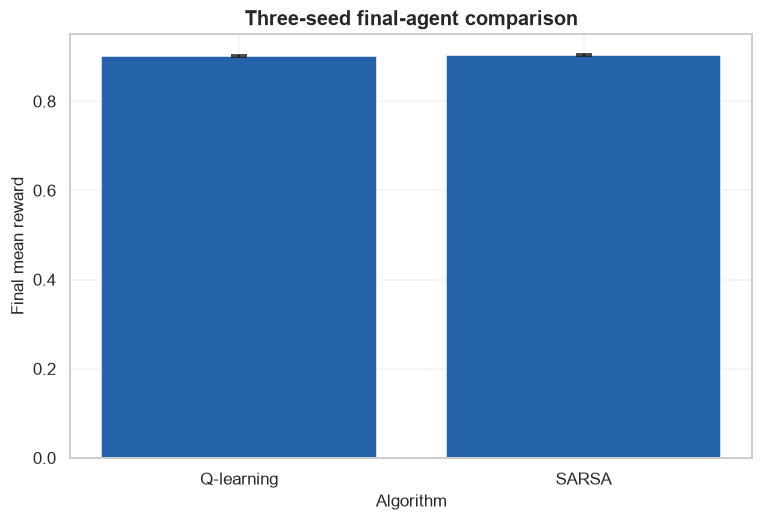

Limitations: one-dimensional states, shaped step cost, fixed slip probability, and only three seeds.


In [4]:
aggregate=summary.groupby("method")["final_reward"].agg(["mean","std"])
figure,axis=plt.subplots(); axis.bar(aggregate.index,aggregate["mean"],yerr=aggregate["std"],capsize=5,color=COURSE_COLORS["blue"])
axis.set(title="Three-seed final-agent comparison",xlabel="Algorithm",ylabel="Final mean reward"); plt.show()
print("Limitations: one-dimensional states, shaped step cost, fixed slip probability, and only three seeds.")

## 18. Common mistakes

            - Starting with a model before defining success
- Fitting preprocessing before splitting
- Selecting on test performance
- Hiding failure modes behind one aggregate score

            ## 19. Advantages and disadvantages

            **Advantages**

            - Reproducible end-to-end evidence
- Explicit comparison and limitations

            **Disadvantages**

            - Benchmark data does not prove deployment readiness
- Offline metrics omit operational costs

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the dataset, metric, and decision are aligned and the result will be treated as evidence rather than certainty.

            **Do not use it when:** unsafe real-world exploration would occur without simulation, constraints, monitoring, and staged evaluation.

## 21. Exercises

1. **Conceptual:** Which decision does the model support?
2. **Mathematical/hand calculation:** Recalculate the primary metric on a tiny example by hand.
3. **Coding/experimentation:** Repeat the final comparison over multiple seeds or splits.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. State the user, action, model output, and consequence in one sentence.
2. Apply the displayed metric to each example, sum, and divide by the correct denominator.
3. Keep preprocessing and candidate definitions fixed, report every run, and summarize mean plus variability.

</details>

## Capstone delivery checklist

- **Business or real-world problem and success metric:** defined before modeling in the problem-definition section.
- **Dataset description and exploratory data analysis:** documented beside the bounded dataset preview and audit outputs.
- **Data cleaning and feature engineering:** performed after the split where fitting or target information could otherwise leak; choices are stated explicitly, including when no cleaning is required.
- **Baseline and multiple-model comparison:** a simple reference model is evaluated before more flexible candidates.
- **Hyperparameter tuning:** candidates are selected only with development or validation evidence.
- **Final evaluation and error analysis:** the frozen choice is assessed on untouched data with a task-appropriate diagnostic plot.
- **Limitations and possible improvements:** recorded with the disadvantages and interpretation so the result is not overstated.
- **Final conclusion:** the summary connects the evidence, limitations, and next steps.

## 23. Summary and key takeaways

            - The workflow is part of the model
- Baselines and data leakage checks precede tuning
- Final evaluation uses untouched data
- Error analysis, limitations, and possible improvements belong in the conclusion

            ## 24. Further reading

            - [scikit-learn model selection](https://scikit-learn.org/stable/model_selection.html)
- [PyTorch tutorials](https://pytorch.org/tutorials/)